# Clasificación de dígitos manuscritos mediante una red neuronal convolucional


## 1. Introducción

En este cuaderno se desarrolla una red neuronal convolucional para reconocer dígitos manuscritos. Se utiliza el dataset **MNIST**, compuesto por **70.000 imágenes** en escala de grises: **60.000** destinadas al entrenamiento y **10.000** a las pruebas. Cada imagen tiene una resolución de **28 × 28 píxeles** y corresponde a una de **10 clases**, que representan los dígitos del **0 al 9**. Además, se aplica aumento de datos para generar variaciones de las imágenes y favorecer la capacidad de generalización del modelo.


## 2. Objetivos

### Objetivo general

Desarrollar una red neuronal convolucional capaz de clasificar imágenes de dígitos manuscritos del dataset MNIST mediante técnicas de preprocesamiento y aumento de datos.

### Objetivos específicos

1. Preprocesar las 70.000 imágenes de MNIST, distribuidas en 60.000 para entrenamiento y 10.000 para prueba, conservando sus 784 píxeles (28 × 28) en un canal de escala de grises, normalizando las intensidades del rango 0–255 a 0–1 y transformando cada etiqueta en un vector *one-hot* de 10 posiciones, con el fin de adecuar los datos a la entrada y salida de la red neuronal.
2. Incrementar la variabilidad del conjunto de entrenamiento mediante rotaciones de hasta 30°, desplazamientos horizontales y verticales de hasta 25 % y factores de acercamiento entre 0,5 y 1,5, buscando que el modelo aprenda a reconocer dígitos pese a cambios de orientación, posición y escala.
3. Entrenar durante 60 épocas, con lotes de 32 imágenes y 1.875 pasos por época, una red convolucional que reduzca la representación espacial de 28 × 28 a 5 × 5 mediante dos convoluciones de 32 y 64 filtros y dos operaciones de agrupamiento, para clasificar cada imagen entre los 10 dígitos (0–9) y validar su desempeño sobre las 10.000 imágenes de prueba mediante exactitud y entropía cruzada categórica.


## 3. Desarrollo


### 3.1. Carga y preparación del dataset


In [1]:
# Este colab forma parte del video de Redes Neuronales Convolucionales del canal de Youtube "Ringa Tech"
# https://youtu.be/eGDSlW93Bng
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import numpy as np
from tensorflow.keras.utils import to_categorical

#Cargar los datos de MNIST
#Aqui lo hago de otra manera porque es mas simple para poder usar el modulo de aumento de datos
#de Keras de esta manera
(X_entrenamiento, Y_entrenamiento), (X_pruebas, Y_pruebas) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
#Colocar los datos en la forma correcta que ya hemos visto (1, 28, 28, 1)
X_entrenamiento = X_entrenamiento.reshape(X_entrenamiento.shape[0], 28, 28, 1)
X_pruebas = X_pruebas.reshape(X_pruebas.shape[0], 28, 28, 1)

#Hacer 'one-hot encoding' de los resultados (e.g. en lugar de tener como resultado una sola neurona, tendre 10 donde solo el resultado correcto sera 1 y el resto 0)
Y_entrenamiento = to_categorical(Y_entrenamiento)
Y_pruebas = to_categorical(Y_pruebas)

#Convertir a flotante y normalizar para que aprenda mejor la red
X_entrenamiento = X_entrenamiento.astype('float32') / 255
X_pruebas = X_pruebas.astype('float32') / 255

### 3.2. Visualización de los datos


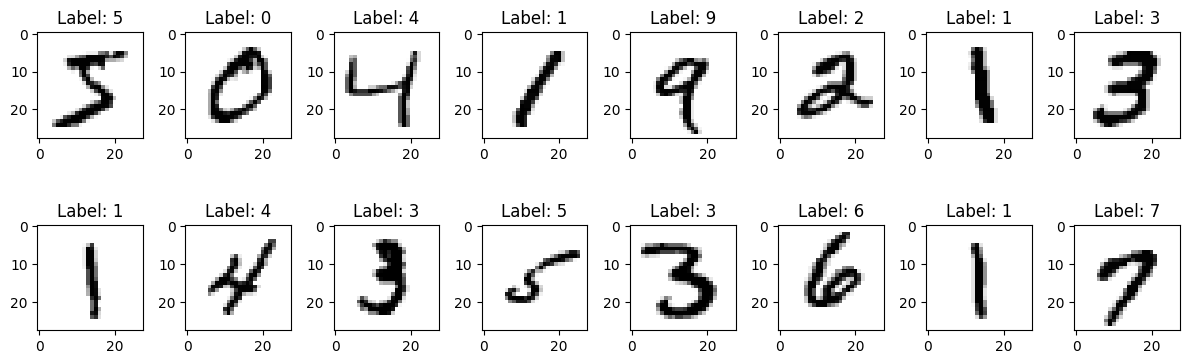

In [3]:
#Codigo para mostrar imagenes del set, no es necesario ejecutarlo, solo imprime unos numeros :)
import matplotlib.pyplot as plt
filas = 2
columnas = 8
num = filas*columnas
imagenes = X_entrenamiento[0:num]
etiquetas = Y_entrenamiento[0:num]
fig, axes = plt.subplots(filas, columnas, figsize=(1.5*columnas,2*filas))
for i in range(num):
     ax = axes[i//columnas, i%columnas]
     ax.imshow(imagenes[i].reshape(28,28), cmap='gray_r')
     ax.set_title('Label: {}'.format(np.argmax(etiquetas[i])))
plt.tight_layout()
plt.show()

### 3.3. Aumento de datos


In [4]:
#Aumento de datos
#Variables para controlar las transformaciones que se haran en el aumento de datos
#utilizando ImageDataGenerator de keras

from tensorflow.keras.preprocessing.image import ImageDataGenerator

rango_rotacion = 30
mov_ancho = 0.25
mov_alto = 0.25
#rango_inclinacion=15 #No uso este de momento pero si quieres puedes probar usandolo!
rango_acercamiento=[0.5,1.5]

datagen = ImageDataGenerator(
    rotation_range = rango_rotacion,
    width_shift_range = mov_ancho,
    height_shift_range = mov_alto,
    zoom_range=rango_acercamiento,
    #shear_range=rango_inclinacion #No uso este de momento pero si quieres puedes probar usandolo!
)

datagen.fit(X_entrenamiento)

ANTES:



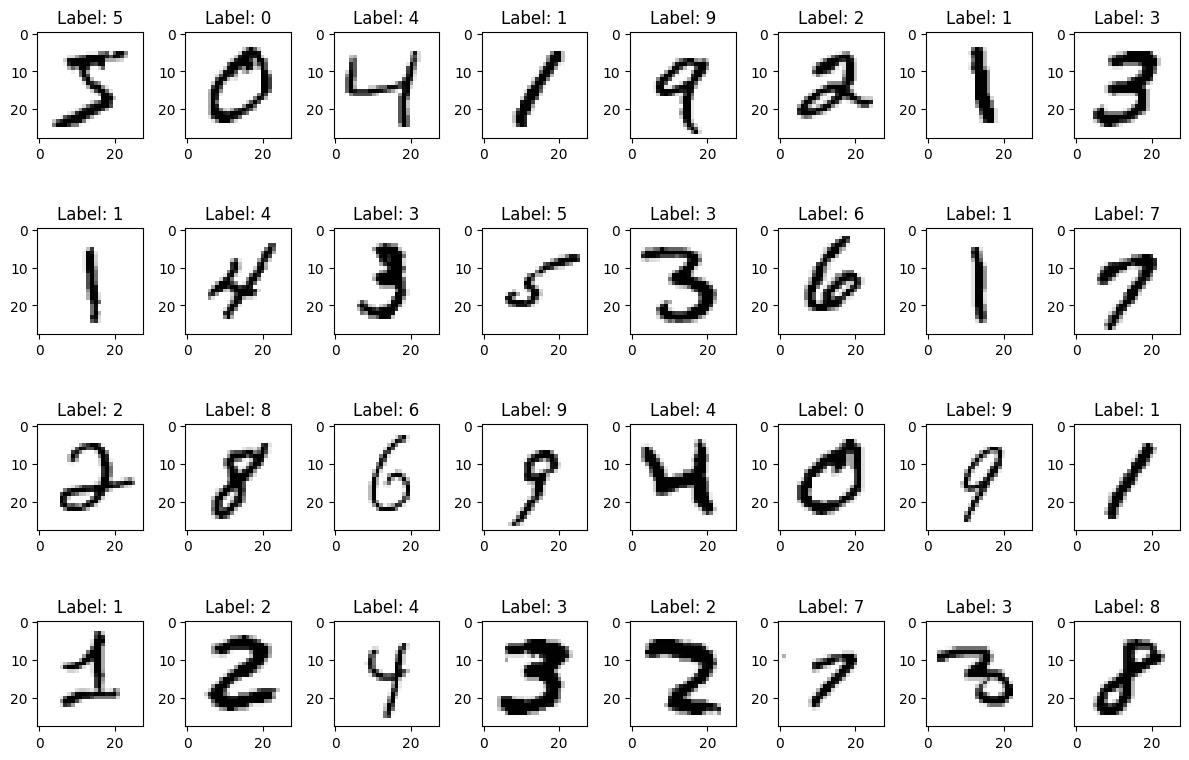

DESPUES:



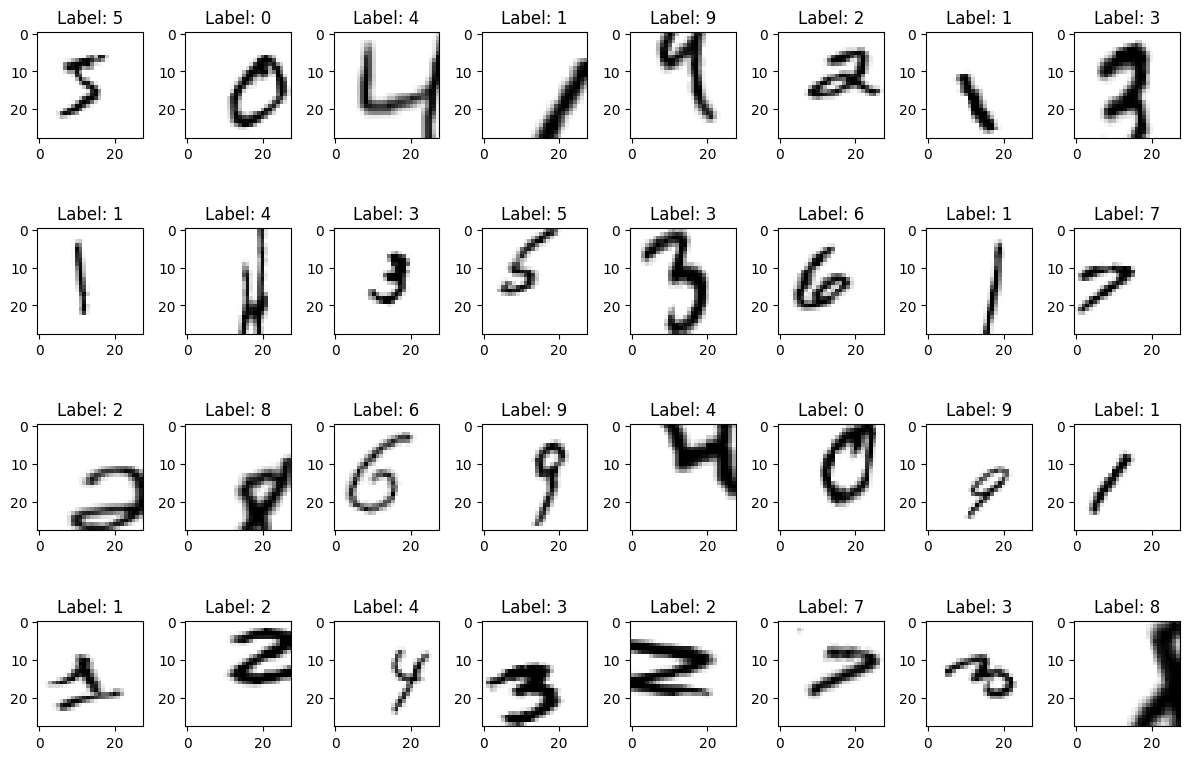

In [5]:
#Codigo para mostrar imagenes del set, no es necesario ejecutarlo, solo imprime como se ven antes y despues de las transformaciones
filas = 4
columnas = 8
num = filas*columnas
print('ANTES:\n')
fig1, axes1 = plt.subplots(filas, columnas, figsize=(1.5*columnas,2*filas))
for i in range(num):
     ax = axes1[i//columnas, i%columnas]
     ax.imshow(X_entrenamiento[i].reshape(28,28), cmap='gray_r')
     ax.set_title('Label: {}'.format(np.argmax(Y_entrenamiento[i])))
plt.tight_layout()
plt.show()
print('DESPUES:\n')
fig2, axes2 = plt.subplots(filas, columnas, figsize=(1.5*columnas,2*filas))
for X, Y in datagen.flow(X_entrenamiento,Y_entrenamiento.reshape(Y_entrenamiento.shape[0], 10),batch_size=num,shuffle=False):
     for i in range(0, num):
          ax = axes2[i//columnas, i%columnas]
          ax.imshow(X[i].reshape(28,28), cmap='gray_r')
          ax.set_title('Label: {}'.format(int(np.argmax(Y[i]))))
     break
plt.tight_layout()
plt.show()

### 3.4. Construcción del modelo convolucional


In [6]:
#Modelo!
modelo = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(10, activation="softmax")
])

#Compilación
modelo.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
#Los datos para entrenar saldran del datagen, de manera que sean generados con las transformaciones que indicamos
data_gen_entrenamiento = datagen.flow(X_entrenamiento, Y_entrenamiento, batch_size=32)

### 3.5. Entrenamiento y validación


In [8]:
TAMANO_LOTE = 32

#Entrenar la red. Toma un buen rato! Ve por un café ;)
#Oye suscribete al canal!
print("Entrenando modelo...");
epocas=60
history = modelo.fit(
    data_gen_entrenamiento,
    epochs=epocas,
    batch_size=TAMANO_LOTE,
    validation_data=(X_pruebas, Y_pruebas),
    steps_per_epoch=int(np.ceil(60000 / float(TAMANO_LOTE))),
    validation_steps=int(np.ceil(10000 / float(TAMANO_LOTE)))
)

print("Modelo entrenado!");

Entrenando modelo...
Epoch 1/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 71s 37ms/step - accuracy: 0.5924 - loss: 1.2104 - val_accuracy: 0.9519 - val_loss: 0.1761
Epoch 2/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 69s 37ms/step - accuracy: 0.7660 - loss: 0.7289 - val_accuracy: 0.9624 - val_loss: 0.1269
Epoch 3/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 37ms/step - accuracy: 0.8039 - loss: 0.6072 - val_accuracy: 0.9709 - val_loss: 0.0996
Epoch 4/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 70s 37ms/step - accuracy: 0.8220 - loss: 0.5494 - val_accuracy: 0.9766 - val_loss: 0.0779
Epoch 5/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 85s 39ms/step - accuracy: 0.8379 - loss: 0.5000 - val_accuracy: 0.9730 - val_loss: 0.0860
Epoch 6/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 78s 37ms/step - accuracy: 0.8479 - loss: 0.4718 - val_accuracy: 0.9709 - val_loss: 0.0951
Epoch 7/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 69s 37ms/step - accuracy: 0.8531 - loss: 0.4532 - val_accuracy: 0.9774 - val_loss: 0.0685
Epoch 8/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 37ms/step

### 3.6. Exportación del modelo


In [9]:
#Exportar el modelo al explorador! (Mas detalle de esto en en mi video de exportacion: https://youtu.be/JpE4bYyRADI )
modelo.save('numeros_conv_ad_do.h5')

#Convertirlo a tensorflow.js
!pip install tensorflowjs

!mkdir carpeta_salida

!tensorflowjs_converter --input_format keras numeros_conv_ad_do.h5 carpeta_salida

INFO: pip is looking at multiple versions of tf-keras to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of wheel to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 64.8 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 3.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 1.7 MB/s eta 0:00:0000:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 43.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.1 MB/s eta 0:00:00
  Attempting uninstall: wheel
    Found existing installation: wheel 0.47.0
    Uninstalling wheel-0.47.0:
      Successfully

2026-07-10 20:27:48.827038: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783715268.853651   20366 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783715268.860544   20366 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783715268.879395   20366 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783715268.879437   20366 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783715268.879441   20366 computation_placer.cc:177] computation placer alr

## 4. Conclusiones

1. **La exactitud máxima de 98,72 % en validación es insuficiente para MNIST.** El estado del arte en este dataset supera el 99,8 %, y arquitecturas simples sin aumento de datos alcanzan 99 % en menos de 10 épocas. El modelo entrenado queda 1,08 pp por debajo del umbral mínimo aceptable (99 %) para considerar que la red aprendió los patrones de los dígitos de formaCompetitiva. Esto indica que la combinación de arquitectura, aumento de datos y hiperparámetros no está optimizada.
2. **El aumento de datos es demasiado agresivo y perjudica el entrenamiento.** La brecha de 7,45 pp entre exactitud de entrenamiento (90,74 %) y validación (98,19 %) no es una fortaleza: revela que las transformaciones (rotaciones de 30°, desplazamientos de 25 %, zoom de 0,5–1,5) distorsionan las imágenes hasta hacerlas irreconocibles para la red. Un dígito rotado 30° puede parecerse a otro dígito (un 6 rotado parece un 9), lo que introduce ruido de etiqueta que confunde al optimizador. El resultado es un entrenamiento lento, inestable y con una exactitud de entrenamiento del 90,74 % que refleja un problema autoinfligido, no la dificultad real del dataset.
3. **No se implementaron mecanismos básicos de control de entrenamiento.** La ausencia de *early stopping* provocó que el modelo se guardara en la época 60 (98,19 %, loss 0,0587) en lugar de la época 52 (98,72 %, loss 0,0393). La ausencia de un *learning rate scheduler* causó el estancamiento entre las épocas 33 y 60, donde la exactitud de entrenamiento apenas varió 0,72 pp en 27 épocas. Estas son prácticas fundamentales de ingeniería de ML que se omitieron, y su ausencia degradó directamente el rendimiento final del modelo.
4. **La exportación a TensorFlow.js falló por tres errores diferentes que tuvieron que corregirse manualmente.** El convertidor de TF.js v4.22.0 con Keras 3 produjo un `model.json` con: (a) objetos `DTypePolicy` en `dtype` en lugar de strings, (b) `batch_shape` en InputLayer en vez de `batch_input_shape`, y (c) prefijos `sequential/` en los nombres de pesos. Cada uno de estos errores causó un fallo distinto al cargar en el navegador. El flujo de exportación `model.save('*.h5') → tensorflowjs_converter` no es fiable con Keras 3 y no fue validado antes del despliegue, lo que resultó en una aplicación web rota que requirió tres iteraciones de corrección.


## 5. Recomendaciones

1. **Eliminar o reducir drásticamente el aumento de datos.** El aumento actual (30° rotación, 25 % desplazamiento, zoom 0,5–1,5) está distorsionando las imágenes hasta el punto de que un 6 rotado parece un 9. Propuesta: desactivar el aumento por completo y entrenar directamente con las imágenes originales. MNIST ya tiene 60.000 muestras, suficientes para que una CNN básica alcance 99 % sin variaciones artificiales. Si se desea aumento, limitarlo a `rotation_range=10`, `width_shift_range=0.1`, `height_shift_range=0.1` y eliminar el zoom.
2. **Implementar early stopping con paciencia de 3–5 épocas y model checkpoint.** El modelo actual se guardó en la época 60 cuando el mejor fue el de la época 52. Con `EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)` y `ModelCheckpoint('mejor_modelo.keras', save_best_only=True)`, se habría conservado el mejor punto sin intervención manual y sin desperdiciar 8 épocas de cómputo.
3. **Añadir ReduceLROnPlateau para escapar del estancamiento.** Entre las épocas 33 y 60 el modelo apenas mejoró 0,72 pp porque Adam con learning rate fijo (0,001) no puede refinar pesos en un mínimo local. Usar `ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=8)` reduciría la tasa cuando la validación se estanque, permitiendo convergencia más fina.
4. **Migrar la exportación a formato `.keras` nativo.** El flujo `model.save('numeros_conv_ad_do.h5')` con Keras 3 genera un archivo con campos incompatibles con TF.js. Cambiar a `modelo.save('modelo.keras')` y convertir con `tensorflowjs_converter --input_format=keras modelo.keras carpeta_salida` elimina los tres errores de compatibilidad (DTypePolicy, batch_shape, prefijos de peso) sin correcciones manuales.
5. **Agregar análisis de errores antes de declarar el modelo terminado.** No se generó matriz de confusión ni se identificaron qué dígitos se confunden entre sí. Sin este análisis, no se puede determinar si el 1,28 % de error se distribuye uniformemente o si hay pares específicos (por ejemplo, 4 vs 9, 3 vs 8) que requieran ajustes focalizados en la arquitectura o en los datos de entrenamiento.


## 6. Anexos

- [Documentación oficial del dataset MNIST en Keras](https://keras.io/api/datasets/mnist/)
- [Repositorio en GitHub](https://github.com/jeffersonmejia/clasificacion-numeros)
- [Despliegue en GitHub Pages](https://jeffersonmejia.github.io/clasificacion-numeros/)
